In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv('9.csv')

from sklearn.model_selection import train_test_split, KFold

X = df.drop(['gb'],axis=1)
y = df['gb']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=df['gb'])
df.head()

,Age,eGFR,ACR,PBG,HbAlc,FT4,TSH,METS-IR,gb
0,66,99.85,12.21,5.39,6.2,12.00,41.24,29.18,1
1,31,101.03,13.05,6.18,6.5,23.67,2.43,71.96,1
2,43,108.92,17.40,6.42,6.1,19.29,0.01,37.26,1
3,55,109.64,5.10,7.23,6.6,13.81,1.84,35.65,0
4,33,119.86,7.37,7.59,6.3,18.21,1.87,57.16,0


In [33]:
# 将测试集特征和目标变量合并为一个 DataFrame
train_data = pd.concat([X_train, y_train], axis=1)
# 保存测试集为 CSV 文件
train_data.to_csv("train_data.csv", index=False)
# 将测试集特征和目标变量合并为一个 DataFrame
test_data = pd.concat([X_test, y_test], axis=1)
# 保存测试集为 CSV 文件
test_data.to_csv("test_data.csv", index=False)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
# 初始化随机森林分类器
clf = RandomForestClassifier(random_state=42)

# 定义StratifiedKFold用于交叉验证
cv = StratifiedKFold(n_splits=5)

# 递归特征消除和交叉验证
rfecv = RFECV(estimator=clf, step=1, cv=cv, scoring='accuracy')
rfecv.fit(X_train, y_train)

# 打印最佳特征数量
print(f"Optimal number of features: {rfecv.n_features_}")

# 获取交叉验证每一折的分数
cv_results = rfecv.cv_results_

# 取出5次交叉验证的单独分数
fold_scores = [cv_results[f'split{i}_test_score'] for i in range(5)]
mean_scores = cv_results['mean_test_score']  # 计算平均得分
# 输出选择的特征列
selected_features = X_train.columns[rfecv.support_]
print(f"Selected features: {list(selected_features)}")
df_selected = df[selected_features]
df_selected.head()

Optimal number of features: 8
Selected features: ['Age', 'eGFR', 'ACR', 'PBG', 'HbAlc', 'FT4', 'TSH', 'METS-IR']


,Age,eGFR,ACR,PBG,HbAlc,FT4,TSH,METS-IR
0,66,99.85,12.21,5.39,6.2,12.00,41.24,29.18
1,31,101.03,13.05,6.18,6.5,23.67,2.43,71.96
2,43,108.92,17.40,6.42,6.1,19.29,0.01,37.26
3,55,109.64,5.10,7.23,6.6,13.81,1.84,35.65
4,33,119.86,7.37,7.59,6.3,18.21,1.87,57.16


In [36]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# 定义一级学习器
base_learners = [
    ("RF", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("XGB", XGBClassifier(n_estimators=100, random_state=42, verbosity=0, use_label_encoder=False)),
    ("LGBM", LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
    ("GBM", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=100, random_state=42)),
    ("CatBoost", CatBoostClassifier(n_estimators=100, random_state=42, verbose=0))  
]

# 定义二级学习器
meta_model = LogisticRegression()

# 创建Stacking分类器
stacking_classifier = StackingClassifier(estimators=base_learners, final_estimator=meta_model, cv=5)

# 训练模型
stacking_classifier.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('RF', RandomForestClassifier(random_state=42)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importa...
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('LGBM',
                                LGBMClassifier(random_state=42, verbose=-1)),
                               ('GBM',
                                GradientBoostingClassifier(random_state=42)),
                               ('AdaBoost',
                                AdaBoostClassifier(n_estimators=100,
                                                   random_state=42)),
                               ('CatBoost',
                                <catboost.core.CatBoostClassifier object at 0x0000023F465BB8D0>)],
                   final_estimator=LogisticRegression())

In [37]:
import joblib
joblib.dump(stacking_classifier, "stacking_classifier_model.pkl")

['stacking_classifier_model.pkl']

Using 221 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/221 [00:00<?, ?it/s]

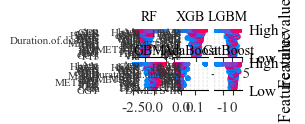

In [10]:
###第一层####基模型
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import numpy as np

# 创建一个字典保存每个模型的 SHAP DataFrame
shap_dfs = {}

# 遍历一级学习器
for name, model in stacking_classifier.named_estimators_.items():
    try:
        if hasattr(model, "predict_proba"):  # 确保模型支持概率预测
            # 判断是否为树模型
            if isinstance(model, (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier, LGBMClassifier, CatBoostClassifier)):
                explainer = shap.TreeExplainer(model)
            else:
                # 使用 KernelExplainer 处理非树模型
                # 对背景数据进行采样，减少计算量
                explainer = shap.KernelExplainer(model.predict_proba, X_test)

            # 计算 SHAP 值
            shap_values = explainer.shap_values(X_test)

            # 处理 SHAP 值的形状问题
            if isinstance(shap_values, list):  # 对于多分类问题，shap_values 是一个列表
                shap_values = shap_values[0]  # 假设只考虑第一个类别的 SHAP 值
            elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:  # 对于某些模型，shap_values 是一个三维数组
                shap_values = shap_values[:, :, 0]  # 假设只考虑第一个类别的 SHAP 值

            # 转化为 DataFrame 保存
            shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
            shap_dfs[name] = shap_df  # 保存每个模型的 SHAP DataFrame

    except Exception as e:
        print(f"Error computing SHAP for model {name}: {e}")

# 绘制 SHAP summary plot
try:
    fig, axes = plt.subplots(2, 3, figsize=(30, 20))
    axes = axes.flatten()
    for i, (name, shap_df) in enumerate(shap_dfs.items()):
        if i >= len(axes):
            break
        plt.sca(axes[i])
        show_color_bar = (i % 3 == 2)
        shap.summary_plot(
            shap_values=shap_df.values,  # 使用 DataFrame 的值
            features=X_test,
            feature_names=X_test.columns,
            plot_type="dot",
            show=False,
            color_bar=show_color_bar
        )
        plt.xlabel('')
        axes[i].set_title(name, fontsize=10)
        axes[i].tick_params(axis='y', labelsize=8)
        if i % 3 != 0:
            axes[i].set_ylabel("")
    plt.tight_layout()
    plt.savefig('第一层.pdf', format='pdf', bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Error plotting SHAP summary: {e}")

In [ ]:
####第二层####元模型
from sklearn.exceptions import NotFittedError
import shap

# 检查 final_estimator_ 是否已经被训练
try:
    meta_model = stacking_classifier.final_estimator_  # 提取已训练好的二级学习器
except AttributeError:
    raise NotFittedError("The final estimator (meta_model) is not yet fitted. Ensure that the StackingClassifier is trained.")

# 获取一级学习器的预测值（作为二级学习器的输入特征）
meta_features = stacking_classifier.transform(X_test)

# 使用 KernelExplainer 解释 LogisticRegression（或其他分类器）
explainer_meta = shap.KernelExplainer(meta_model.predict_proba, meta_features)

# 计算二级学习器的 SHAP 值
shap_values_meta = explainer_meta.shap_values(meta_features)

In [ ]:
shap_df = pd.DataFrame(shap_values_meta, columns=[f"Feature {i}" for i in range(meta_features.shape[1])])
shap_df

In [ ]:
plt.figure()
shap.summary_plot(
    np.array(shap_df),  # SHAP 值
    shap_df,           # 数据集（特征值）
    feature_names=shap_df.columns,  # 特征名称
    plot_type="dot",   # 使用点图
    show=False         # 不立即显示，便于添加自定义标题
)

# 添加标题
plt.title("SHAP Contribution Analysis for the Meta-Learner in the Second Layer of Stacking Classifier", 
          fontsize=16, y=1.02)

# 保存图像
plt.savefig("SHAP Contribution Analysis for the Meta-Learner in the Second Layer of Stacking Classifier.png", 
            bbox_inches='tight', dpi=1200)

# 显示图像
plt.show()

In [ ]:
###整体###
# 使用 SHAP 的 KernelExplainer 对 Stacking 模型整体进行解释（代理模型方法）
# 这里只计算了100个样本节省时间
stacking_explainer = shap.KernelExplainer(stacking_classifier.predict_proba, X_test)

# 计算 SHAP 值（解释 Stacking 模型对输入特征的贡献）
stacking_shap_values = stacking_explainer.shap_values(X_test)

# 选择正类的 SHAP 值
stacking_shap_values = stacking_shap_values[1]

# 转化为 DataFrame 保存
stacking_shap_df = pd.DataFrame(stacking_shap_values, columns=X_test.columns)
stacking_shap_df
# 可视化
plt.figure(figsize=(10, 8))
shap.summary_plot(np.array(stacking_shap_df), stacking_shap_df, feature_names=stacking_shap_df.columns, plot_type="dot", show=False)
plt.title("Based on the overall feature contribution analysis of SHAP to the stacking model", fontsize=16, y=1.02)
plt.savefig("Based on the overall feature contribution analysis of SHAP to the stacking model.png", format='png', bbox_inches='tight', dpi=1200)
plt.show()

Using 221 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/221 [00:00<?, ?it/s]

In [ ]:
##整体力图
import shap
import matplotlib.pyplot as plt

# 创建解释器
stacking_explainer = shap.KernelExplainer(stacking_classifier.predict_proba, X_test)

# 计算 SHAP 值
stacking_shap_values = stacking_explainer.shap_values(X_test)

# 选择样本
sample_index = 0

# 绘制力图
shap.force_plot(
    stacking_explainer.expected_value[0],  # 使用解释器的 expected_value
    stacking_shap_values[sample_index,:,0],  # 使用正确的 SHAP 值
    X_test.iloc[sample_index],  # 选择对应的样本特征
    matplotlib=True,
    show=False
)

# 保存图像
plt.savefig("00力图.pdf", format='pdf', bbox_inches='tight')


In [15]:
#####分类模型性能评价######
#########################
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification

# 初始化结果存储
results = []

# 定义函数计算并保存指标
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # 计算指标
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr') if y_prob is not None else np.nan

    # 存储结果
    results.append({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "Model": model_name})

# 1. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
evaluate_model("RF", rf, X_test, y_test)

# 2. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
evaluate_model("XGB", xgb, X_test, y_test)

# 3. LightGBM
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
evaluate_model("LightGBM", lgbm, X_test, y_test)

# 4. Gradient Boosting (GBM)
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)
evaluate_model("GBM", gbm, X_test, y_test)

# 5. AdaBoost
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
evaluate_model("AdaBoost", ada, X_test, y_test)

# 6. CatBoost
cat = CatBoostClassifier(verbose=0, random_state=42)
cat.fit(X_train, y_train)
evaluate_model("CatBoost", cat, X_test, y_test)

#7. stacking
stacking_classifier = StackingClassifier(estimators=base_learners, final_estimator=meta_model, cv=5)
stacking_classifier.fit(X_train, y_train)
evaluate_model("Stacking", stacking_classifier, X_test, y_test)

# 将结果转换为 DataFrame 并显示
results_df = pd.DataFrame(results)
print(results_df)

   Accuracy  Precision    Recall  F1-score   ROC-AUC     Model
0  0.638009   0.639593  0.638009  0.637490  0.719856        RF
1  0.588235   0.589677  0.588235  0.587492  0.634420       XGB
2  0.633484   0.640571  0.633484  0.630004  0.708798  LightGBM
3  0.638009   0.642573  0.638009  0.635999  0.722969       GBM
4  0.647059   0.648180  0.647059  0.646770  0.702122  AdaBoost
5  0.651584   0.659433  0.651584  0.648275  0.729440  CatBoost
6  0.638009   0.643576  0.638009  0.635474  0.730095  Stacking


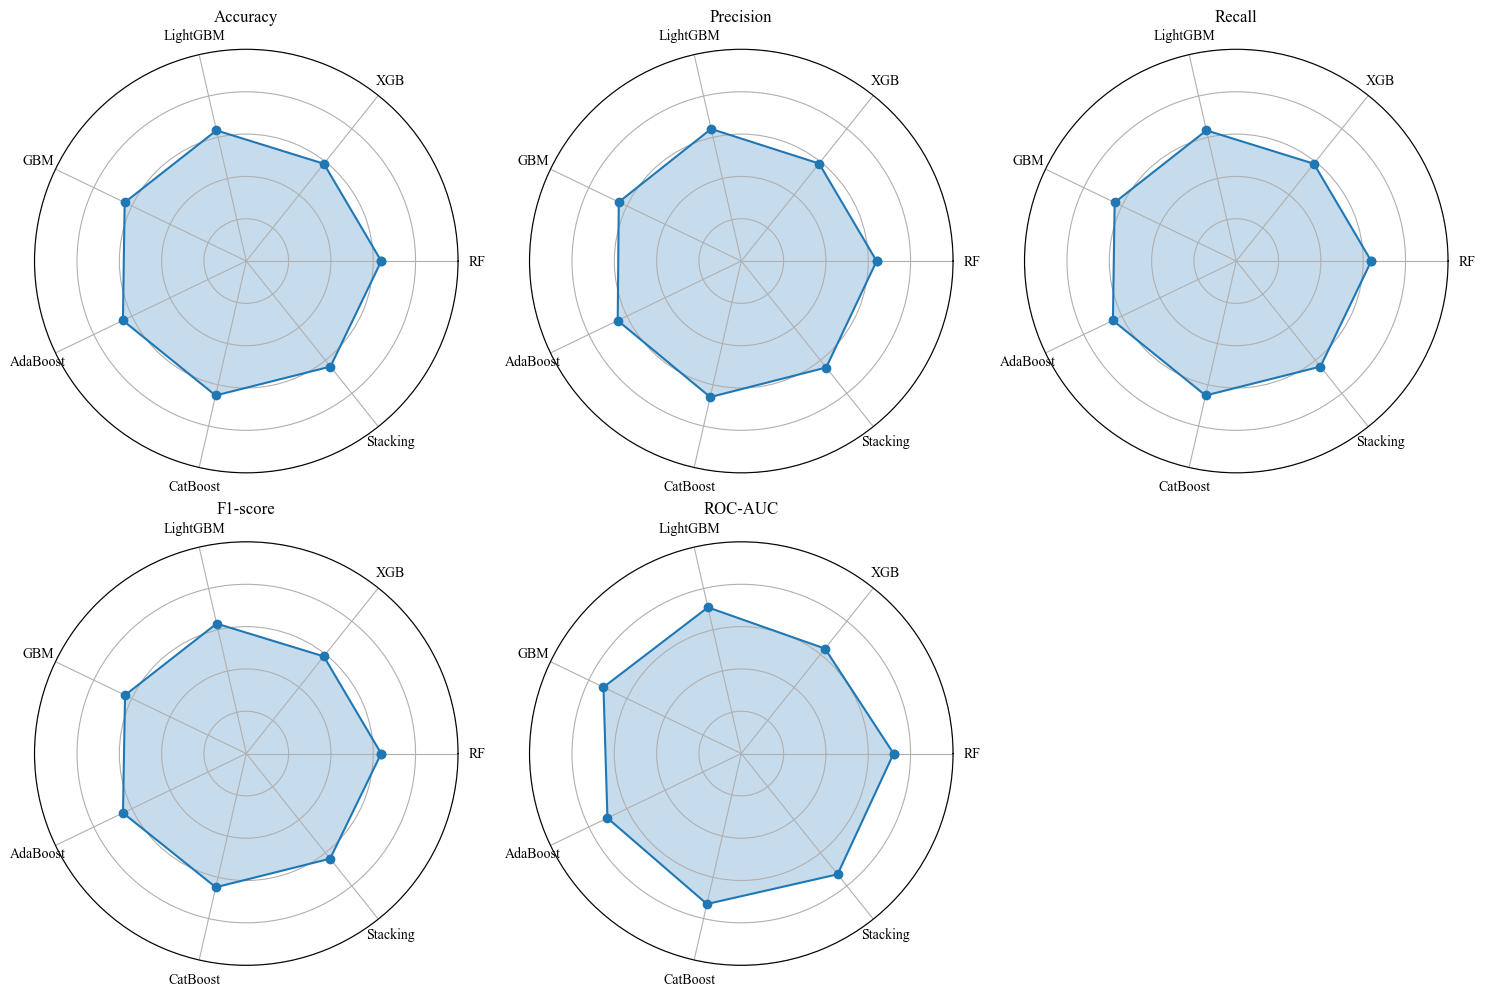

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
categories = results_df["Model"].tolist()
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  

fig, axs = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric].tolist()
    values += values[:1]  # Close the radar
    axs[i].fill(angles, values, alpha=0.25, label=metric)
    axs[i].plot(angles, values, marker='o')
    axs[i].set_ylim(0, 1.001)
    axs[i].set_xticks(angles[:-1])
    axs[i].set_xticklabels(categories, fontsize=10)
    axs[i].set_title(metric, pad=20)
    axs[i].set_yticklabels([])

fig.delaxes(axs[-1])
plt.savefig("模型性能比较1.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.tight_layout()
plt.show()

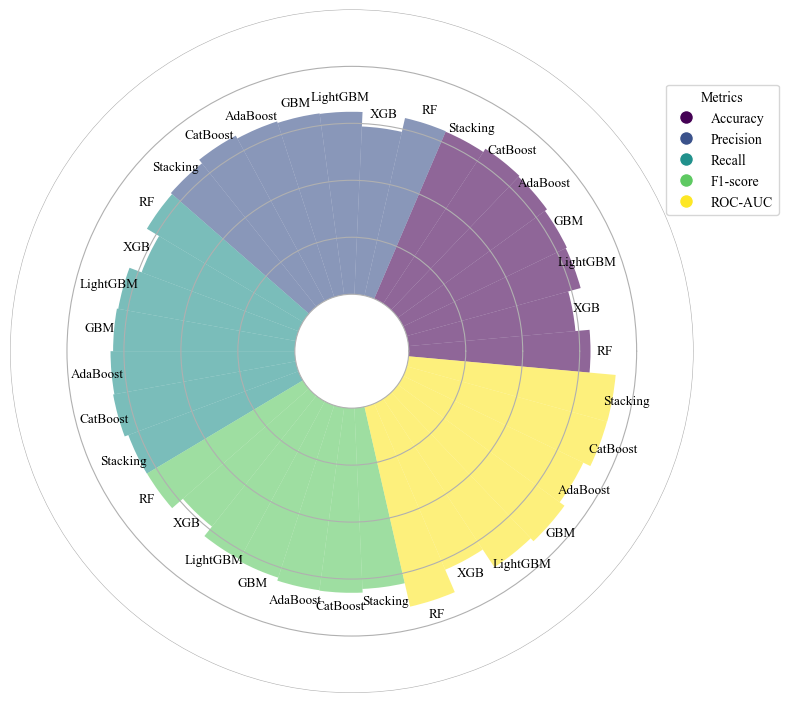

In [17]:
from matplotlib.lines import Line2D
from matplotlib import cm
def plot_polar_bars(data, num_metrics, num_models):
    """
    绘制极坐标柱状图，展示各模型在不同指标上的表现，并在顶部标注模型名称。
    
    参数:
    - data: 包含模型得分的 DataFrame，必须包含 'Model' 列和指标列
    - num_metrics: 指标数量
    - num_models: 模型数量
    """
    models = data['Model'].tolist()
    metrics = data.columns[:-1].tolist()  # 指标列
 # 检查输入的指标和模型数量是否正确
    assert len(metrics) == num_metrics, f"Expected {num_metrics} metrics, but got {len(metrics)}"
    assert len(models) == num_models, f"Expected {num_models} models, but got {len(models)}"

    # 设置极坐标图
    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形

    # 设置颜色
    colors = cm.viridis(np.linspace(0, 1, num_metrics))

    # 图形设置
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 固定最外圈半径
    outer_radius = 1.2
    inner_radius = 0.2
    max_value = data.iloc[:, :-1].values.max()

    # 确保数据范围在可绘制范围内
    assert max_value + inner_radius <= outer_radius, \
        f"Data values exceed maximum allowed range (outer_radius = {outer_radius})"

    # 每个柱的宽度
    bar_width = (2 * np.pi / num_metrics) / num_models

    # 绘制柱状图
    for i, metric in enumerate(metrics):
        values = data[metric].tolist()
        angle = angles[i]
        for j, value in enumerate(values):
            offset_angle = angle + j * bar_width
            ax.bar(offset_angle, value, bottom=inner_radius, width=bar_width, label=models[j] if i == 0 else "",
                   alpha=0.6, color=colors[i])

            # 添加顶部标签
            ax.text(offset_angle, inner_radius + value + 0.05, models[j],
                    ha='center', va='center', fontsize=9.5, rotation=0)

    # 设置极坐标轴属性
    ax.set_ylim(0, outer_radius)
    ax.set_yticklabels([])
    ax.set_xticks([])

    # 添加图例
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=10, label=metrics[i]) 
        for i in range(num_metrics)
    ]
    ax.legend(handles=legend_elements, title='Metrics', bbox_to_anchor=(0.95, 0.9), loc='upper left')
    ax.spines['polar'].set_visible(False)

    plt.tight_layout()
    plt.savefig("模型性能比较2.pdf", format='pdf', bbox_inches='tight', dpi=1200)
    plt.show()

plot_polar_bars(results_df, 5, 7)